In [ ]:
# --- 1. SETUP ---
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Define the EXACT project paths from your video
project_path = '/content/drive/MyDrive/GenomeDetector'
# IMPORTANT: We are now using the 'natural2' folder
natural_data_path = os.path.join(project_path, 'data', 'natural2')
engineered_data_path = os.path.join(project_path, 'data', 'engineered')

# Install the necessary library
!pip install biopython

print("Environment is ready. Paths are set to your 'natural2' and 'engineered' folders.")

Mounted at /content/drive
Environment is ready. Paths are set to your 'natural2' and 'engineered' folders.


In [ ]:
import numpy as np
from itertools import product
from Bio import SeqIO
import glob
import os
import gzip

def get_kmer_features(k):
    """Generates all possible k-mers for a given k."""
    letters = ['A', 'C', 'G', 'T']
    return sorted([''.join(p) for p in product(letters, repeat=k)])

def sequence_to_kmer_counts(sequence, k, kmer_features):
    """Converts a DNA sequence into a vector of k-mer counts."""
    kmer_counts = {kmer: 0 for kmer in kmer_features}
    for i in range(len(sequence) - k + 1):
        kmer = sequence[i:i+k].upper()
        if kmer in kmer_counts:
            kmer_counts[kmer] += 1
    return list(kmer_counts.values())

# --- Main Loading Logic ---
print("--- Loading and Processing Your Datasets ---")
K_VALUE = 4
kmer_features = get_kmer_features(K_VALUE)
X, y = [], []

# 1. Load Natural Data from 'natural2' (handles .fna and .fna.gz)
print("Loading 'Natural' genomes from the 'natural2' folder...")
# The '*' wildcard finds files ending in .fna or .fna.gz
search_pattern_natural = f"{natural_data_path}/*.fna*"
natural_files = glob.glob(search_pattern_natural)

for filepath in natural_files:
    # Open the file correctly, whether it's gzipped or not
    handle = gzip.open(filepath, "rt") if filepath.endswith(".gz") else open(filepath, "r")
    for record in SeqIO.parse(handle, "fasta"):
        if len(record.seq) > 1000:
            X.append(sequence_to_kmer_counts(str(record.seq), K_VALUE, kmer_features))
            y.append(0) # Label 0 for Natural
    handle.close()

# 2. Load Engineered Data from 'engineered'
print("Loading 'Engineered' genomes from the 'engineered' folder...")
search_pattern_engineered = f"{engineered_data_path}/*.fasta"
engineered_files = glob.glob(search_pattern_engineered)

for filepath in engineered_files:
    for record in SeqIO.parse(filepath, "fasta"):
        if 200 < len(record.seq) < 50000:
            X.append(sequence_to_kmer_counts(str(record.seq), K_VALUE, kmer_features))
            y.append(1) # Label 1 for Engineered

X = np.array(X)
y = np.array(y)

print("\n--- Data Processing Complete! ---")
print(f"Shape of our final feature matrix X: {X.shape}")
print(f"Shape of our final label vector y: {y.shape}")
print(f"Number of Natural samples (class 0): {np.sum(y == 0)}")
print(f"Number of Engineered samples (class 1): {np.sum(y == 1)}")

--- Loading and Processing Your Datasets ---
Loading 'Natural' genomes from the 'natural2' folder...
Loading 'Engineered' genomes from the 'engineered' folder...

--- Data Processing Complete! ---
Shape of our final feature matrix X: (9017, 256)
Shape of our final label vector y: (9017,)
Number of Natural samples (class 0): 8151
Number of Engineered samples (class 1): 866



--- A1: Evaluating Confusion Matrix and Performance Metrics ---

--- Performance on TEST Set ---
Confusion Matrix:
 [[2443    3]
 [  10  250]]
Precision: 0.9881, Recall: 0.9615, F1-Score: 0.9747

--- Performance on TRAIN Set ---
Precision: 0.9983, Recall: 0.9703, F1-Score: 0.9841

Inference: Model shows a REGULAR FIT.

--- A3: Synthetic Training Data ---


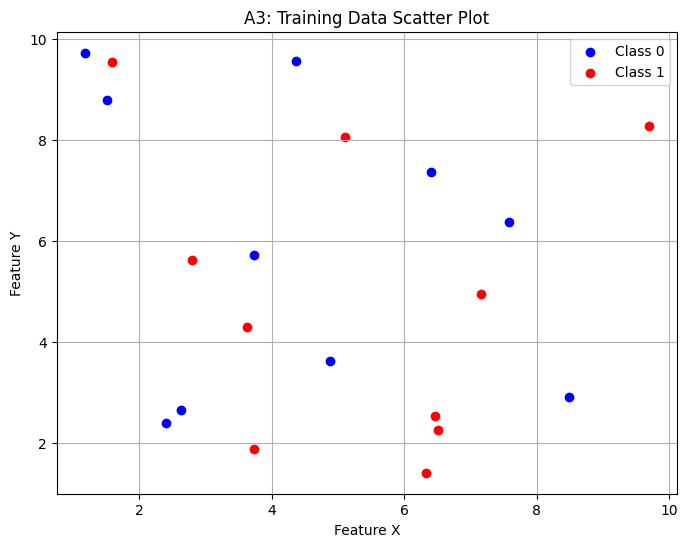


--- A4: Predicting Test Grid (k=3) ---


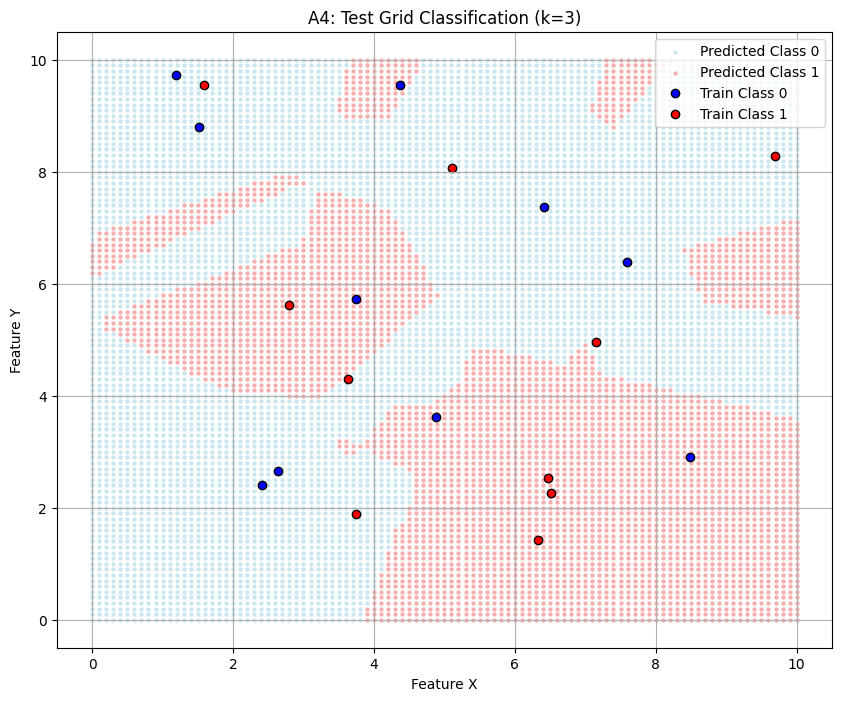


--- A5: Boundary Visualization for Different k ---


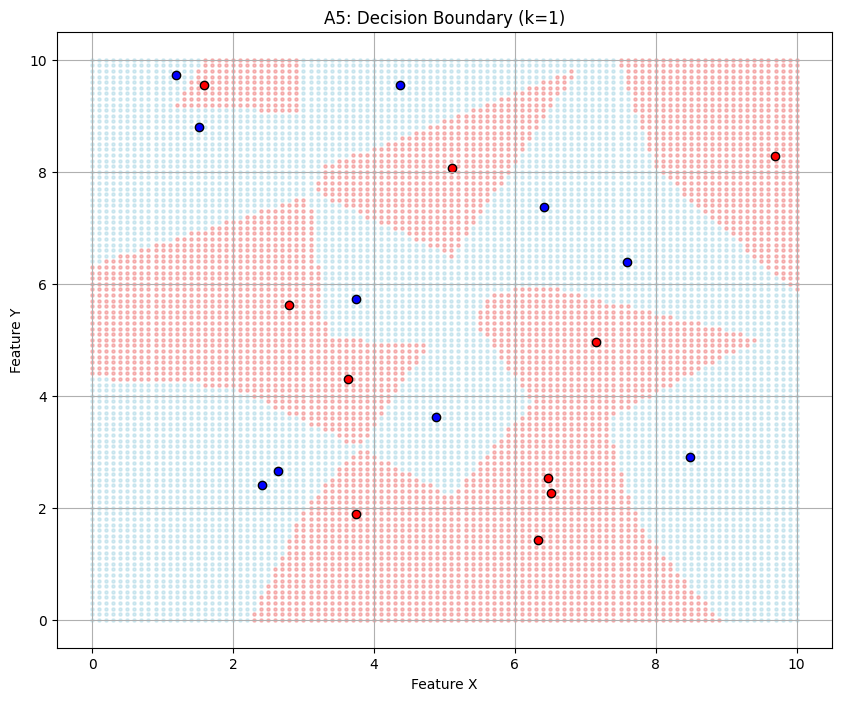

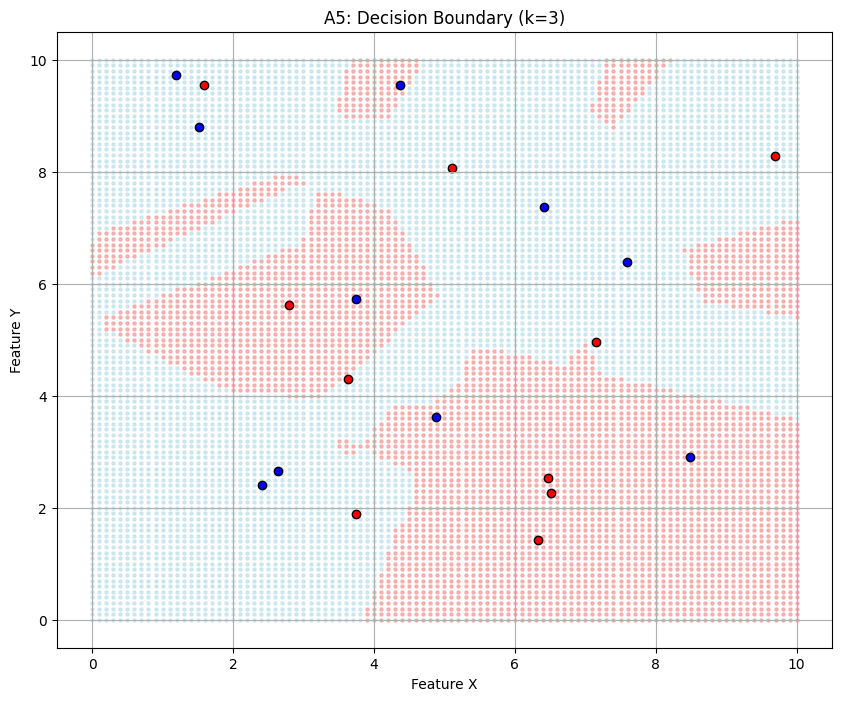

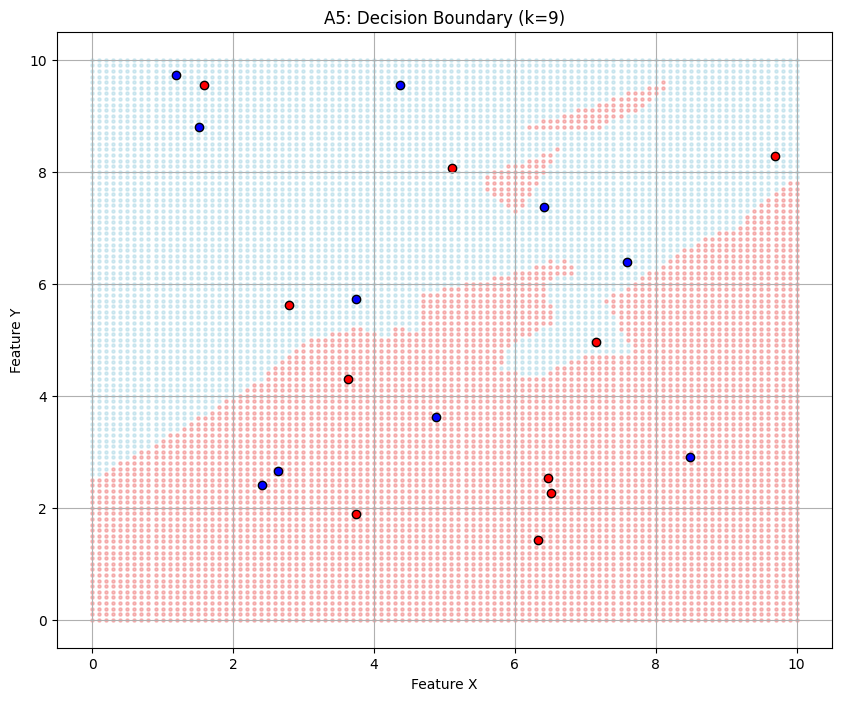

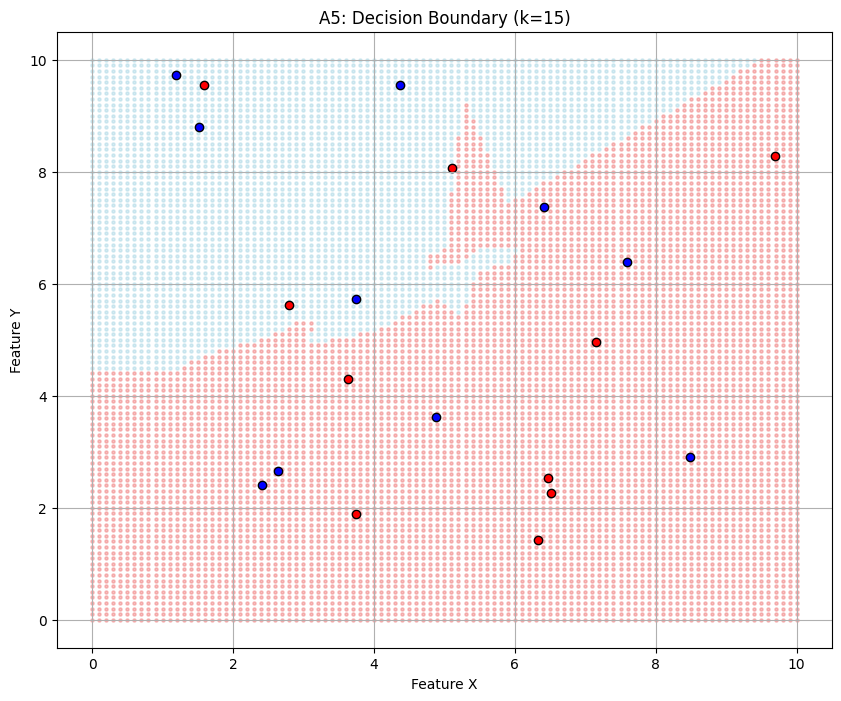


--- A6: Visualizing Decision Boundaries for Project Data ---


In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

# A1: Performance on Project Data
if 'X' not in locals() or X.shape[0] == 0:
    print("ERROR: Data variables 'X' and 'y' not found or are empty.")
else:
    print("\n--- A1: Evaluating Confusion Matrix and Performance Metrics ---")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    knn = KNeighborsClassifier(n_neighbors=3).fit(X_train, y_train)
    y_pred_test = knn.predict(X_test)
    y_pred_train = knn.predict(X_train)
    cm_test = confusion_matrix(y_test, y_pred_test)
    precision_test, recall_test, f1_test, _ = precision_recall_fscore_support(y_test, y_pred_test, average='binary')
    precision_train, recall_train, f1_train, _ = precision_recall_fscore_support(y_train, y_pred_train, average='binary')

    print("\n--- Performance on TEST Set ---")
    print("Confusion Matrix:\n", cm_test)
    print(f"Precision: {precision_test:.4f}, Recall: {recall_test:.4f}, F1-Score: {f1_test:.4f}")

    print("\n--- Performance on TRAIN Set ---")
    print(f"Precision: {precision_train:.4f}, Recall: {recall_train:.4f}, F1-Score: {f1_train:.4f}")

    if f1_train > f1_test + 0.1:
        print("\nInference: Model shows signs of OVERFITTING.")
    else:
        print("\nInference: Model shows a REGULAR FIT.")

# A3: Synthetic Training Data (2 Classes, 2 Features)
print("\n--- A3: Synthetic Training Data ---")
np.random.seed(42)
X_train_small = np.random.uniform(1, 10, (20, 2))
y_train_small = np.array([0 if i < 10 else 1 for i in range(20)])
plt.figure(figsize=(8, 6))
plt.scatter(X_train_small[y_train_small==0][:, 0], X_train_small[y_train_small==0][:, 1], color='blue', label='Class 0')
plt.scatter(X_train_small[y_train_small==1][:, 0], X_train_small[y_train_small==1][:, 1], color='red', label='Class 1')
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.title("A3: Training Data Scatter Plot")
plt.legend()
plt.grid(True)
plt.show()

# A4: Test Grid + k-NN Prediction with k=3
print("\n--- A4: Predicting Test Grid (k=3) ---")
x_vals = np.arange(0, 10.1, 0.1)
y_vals = np.arange(0, 10.1, 0.1)
xx, yy = np.meshgrid(x_vals, y_vals)
test_grid = np.c_[xx.ravel(), yy.ravel()]
knn_synth = KNeighborsClassifier(n_neighbors=3).fit(X_train_small, y_train_small)
pred_grid = knn_synth.predict(test_grid)
plt.figure(figsize=(10, 8))
plt.scatter(test_grid[pred_grid==0][:, 0], test_grid[pred_grid==0][:, 1], color='lightblue', label='Predicted Class 0', s=5, alpha=0.5)
plt.scatter(test_grid[pred_grid==1][:, 0], test_grid[pred_grid==1][:, 1], color='lightcoral', label='Predicted Class 1', s=5, alpha=0.5)
plt.scatter(X_train_small[y_train_small==0][:, 0], X_train_small[y_train_small==0][:, 1], color='blue', edgecolor='k', label='Train Class 0')
plt.scatter(X_train_small[y_train_small==1][:, 0], X_train_small[y_train_small==1][:, 1], color='red', edgecolor='k', label='Train Class 1')
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.title("A4: Test Grid Classification (k=3)")
plt.legend()
plt.grid(True)
plt.show()

# A5: Repeat A4 for k = 1, 3, 9, 15
print("\n--- A5: Boundary Visualization for Different k ---")
for k_val in [1, 3, 9, 15]:
    knn = KNeighborsClassifier(n_neighbors=k_val).fit(X_train_small, y_train_small)
    preds = knn.predict(test_grid)
    plt.figure(figsize=(10, 8))
    plt.scatter(test_grid[preds==0][:, 0], test_grid[preds==0][:, 1], color='lightblue', s=5, alpha=0.5)
    plt.scatter(test_grid[preds==1][:, 0], test_grid[preds==1][:, 1], color='lightcoral', s=5, alpha=0.5)
    plt.scatter(X_train_small[y_train_small==0][:, 0], X_train_small[y_train_small==0][:, 1], color='blue', edgecolor='k')
    plt.scatter(X_train_small[y_train_small==1][:, 0], X_train_small[y_train_small==1][:, 1], color='red', edgecolor='k')
    plt.xlabel("Feature X")
    plt.ylabel("Feature Y")
    plt.title(f"A5: Decision Boundary (k={k_val})")
    plt.grid(True)
    plt.show()

# A6: Decision Boundaries for Project Data (k-mers)
print("\n--- A6: Visualizing Decision Boundaries for Project Data ---")
feature_idx1, feature_idx2 = 15, 50
X_2d = X[:, [feature_idx1, feature_idx2]]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.3, random_state=42, stratify=y)
feature_names_2d = [get_kmer_features(K_VALUE)[feature_idx1], get_kmer_features(K_VALUE)[feature_idx2]]

def plot_boundary(X_2d_plot, y_plot, classifier, k_val, f_names):
    cmap_light = ListedColormap(['#d8e8ff','#ffdede'])
    cmap_bold = ListedColormap(['#0000FF','#FF0000'])
    h = 0.5
    x_min, x_max = X_2d_plot[:, 0].min() - 5, X_2d_plot[:, 0].max() + 5
    y_min, y_max = X_2d_plot[:, 1].min() - 5, X_2d_plot[:, 1].max() + 5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, cmap=cmap_light)
    plt.scatter(X_2d_plot[:, 0], X_2d_plot[:, 1], c=y_plot, cmap=cmap_bold, edgecolor='k', s=25, alpha=0.7)
    plt.title(f"A6: Project k-NN Boundary (k={k_val})")
    plt.xlabel(f"Count of '{f_names[0]}'")
    plt.ylabel(f"Count of '{f_names[1]}'")
    plt.show()

for k_val in [1, 5, 25]:
    knn_2d = KNeighborsClassifier(n_neighbors=k_val).fit(X_train_2d, y_train_2d)
    plot_boundary(X_test_2d, y_test_2d, knn_2d, k_val, feature_names_2d)

# A7: Hyperparameter Tuning on Project Data
print("\n--- A7: Finding the Optimal 'k' with GridSearchCV ---")
param_grid = {'n_neighbors': np.arange(1, 21, 2)}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)
print(f"The best value for 'k' found is: {grid_search.best_params_['n_neighbors']}")
print(f"This best 'k' achieved a cross-validated F1-score of: {grid_search.best_score_:.4f}")
